In [ ]:
# load test (true solution + ROM solution)
# convolve ROM to get sROM solution
# width = sigma + characteristic_disctance  
# iterate over pixels:
    # if val < threshold:
        # s, e = i-width, i+width
        # window = sROM[s:e, s:e]
        # mask = window > threshold & window < 1
        # window[mask] = window[mask]/np.sum(window[mask])*(np.sum(window[mask])+val)
        # sROM[i, j] = 0

In [2]:
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.colors import rgb2hex
from mpl_toolkits.axes_grid1 import make_axes_locatable
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from scipy.interpolate import griddata
from datetime import datetime
from smooth_POD_ROM.pre_processing import (
    on_regular_grid, _gauss_2d, to_frequency, to_space, add_padding)
from smooth_POD_ROM.post_processing import sharpen
from smooth_POD_ROM.io import get_data, get_field
from smooth_POD_ROM.plotting import plot_mesh, plot_field, plot_structured_field
from copy import deepcopy
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import wiener, convolve2d
from skimage import restoration
from skimage.restoration import richardson_lucy
import tvtk
import cv2
from datetime import datetime
from os import listdir
from os.path import isfile, join
import re
import seaborn as sn
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.cm.viridis_r
#cmap.set_over('red')

page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (page_width_in/2, page_width_in/3)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 25

8.030570172000001


In [4]:
mypath = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
onlyfiles = [f for f in listdir(mypath) if f.endswith(".txt")]
t = []
e_ROM = []
e_sROMs = []
for file in onlyfiles:
    if file.startswith("db_sROMs_"):
        e_sROMs.append(np.genfromtxt(mypath+file))
    elif file.startswith("db_ROM"):
        e_ROM.append(np.genfromtxt(mypath+file))
        t.append(float(file[14:18]))
e_ROM = np.array(e_ROM)
e_sROMs = np.array(e_sROMs)
t = np.array(t)

In [10]:
for i in range(len(t)):
    print(t[i], np.mean(e_sROMs[i, :])/np.mean(e_ROM[i, :]))

0.05 1.0169894464083875
0.1 0.9445758367863918
0.15 0.9384418466821062
0.2 0.944247042475139
0.25 0.9370503620187052
0.3 0.9299484289496204
0.3 0.9288779929735864
0.35 0.9039447439966526
0.4 0.9049861962786941
0.45 0.9152084724978102
0.5 0.9254813262591418
0.55 0.9382256886424362


In [6]:
d = {}
error = np.r_[e_ROM, e_sROMs]
time = np.ones_like(error)*np.r_[t, t][:, None]
dataset = np.empty(error.shape, dtype='object')
print(dataset.shape)
dataset[:len(t), :] = "standard"
dataset[len(t):, :] = "smooth"
d["error"] = error.ravel()
d["time [s]"] = time.ravel()
d["ROM type"] = dataset.ravel()
df = pd.DataFrame(d)
df

(24, 180)


,error,time [s],ROM type
0,0.018734,0.05,standard
1,0.011719,0.05,standard
2,0.012956,0.05,standard
3,0.006766,0.05,standard
4,0.006766,0.05,standard
...,...,...,...
4315,0.247022,0.55,smooth
4316,0.081565,0.55,smooth
4317,0.143896,0.55,smooth
4318,0.127298,0.55,smooth


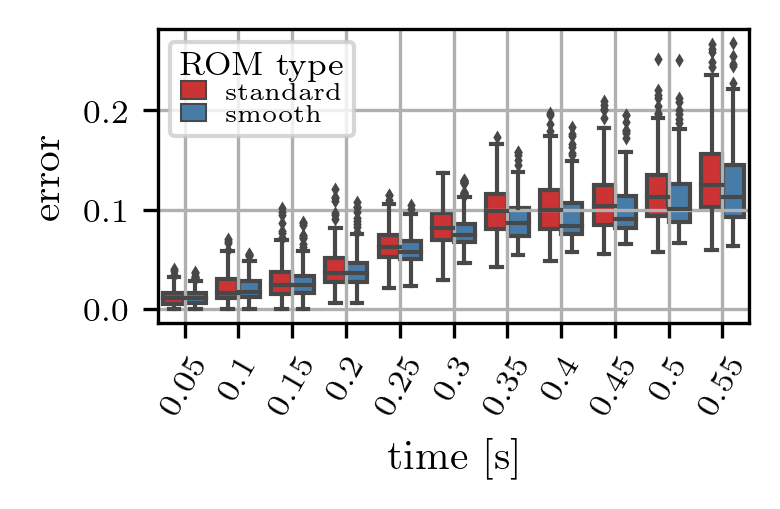

In [7]:
# Add a dark grid
#sns.set(style="darkgrid")
fig =plt.figure(figsize=(page_width_in/2, page_width_in/3))
# Create and display the plot
sn.boxplot(x="time [s]",
            y="error",
            hue="ROM type",
            data=df,
            palette="Set1",
            fliersize=1,
            linewidth=1,
            width=0.8)
#plt.legend(title='Model', labels=['Hell Yeh', 'Nah Bruh', 'wut?', 'no comprendo?', "s", "sa", "asd"])
plt.xticks(rotation=60)
plt.xticks(fontsize=8)  # Adjust x-axis tick label font size
plt.yticks(fontsize=8)  # Adjust y-axis tick label font size
legend = plt.gca().get_legend()
legend.get_title().set_fontsize('8')  # Set font size to 10
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.show()